In [2]:
import numpy as np
import pandas as pd
import mlflow
import matplotlib.pyplot as plt

In [4]:
mlflow.autolog()

**<h2>Data<h2>** 
    
**<h4> Episodes<h4>** 

In this section I worked on preparing the dataframe for all of the episodes in the series

In [5]:
episodes = pd.read_json("episodes.json")
episodes = pd.json_normalize(episodes["episodes"])
scenes = pd.DataFrame(episodes["scenes"])
scenes = scenes["scenes"]

In [6]:
# Drop unnecessary columns
episodes = episodes.drop(['episodeTitle',
                          'episodeLink',
                          'episodeAirDate',
                          'episodeDescription'], axis=1)

# Taking a look at the episode data frame
episodes.head()

,seasonNum,episodeNum,openingSequenceLocations,scenes
0,1,1,"[King's Landing, Winterfell, The Wall, Pentos]","[{'sceneStart': '0:00:40', 'sceneEnd': '0:01:4..."
1,1,2,"[King's Landing, Winterfell, The Wall, Vaes Do...","[{'sceneStart': '0:02:22', 'sceneEnd': '0:05:2..."
2,1,3,"[King's Landing, Winterfell, The Wall, Vaes Do...","[{'sceneStart': '0:01:47', 'sceneEnd': '0:02:4..."
3,1,4,"[King's Landing, Winterfell, The Wall, Vaes Do...","[{'sceneStart': '0:01:47', 'sceneEnd': '0:02:3..."
4,1,5,"[King's Landing, The Eyrie, Winterfell, The Wa...","[{'sceneStart': '0:01:53', 'sceneEnd': '0:02:1..."


Experiment with code needed to add total deaths to episodes (loop down below, just above machine learning portion)

In [492]:
np.max(episodes[episodes['seasonNum'] == 7]['episodeNum'].unique())

7

This code won't work in its current position, but I was experimenting with it to create a loop, which I eventually moved to a different section of the notebook (just before the machine learning portion)

In [525]:
np.sum(all_scenes[(all_scenes['Episode Number'] == 3) & (all_scenes['Season Number'] == 2)]['Death in Scene'])

2

Drop the columns that contain lists (scenes will be dealth with in a different dataframe)

In [7]:
episodes = episodes.drop(['openingSequenceLocations', 'scenes'], axis=1)
episodes

,seasonNum,episodeNum
0,1,1
1,1,2
2,1,3
3,1,4
4,1,5
...,...,...
68,8,2
69,8,3
70,8,4
71,8,5


**<h4>Scenes<h4>**

In this section, I started practing working with the scenes dataset in order to eventually create a dataframe of all the scenes

In [580]:
# Check how many total scenes there are to confirm total rows in
# all_scenes
num_scenes = 0
for episode in range(len(episodes)):
    num_scenes += len(scenes[episode])

num_scenes

4165

In [581]:
# Extract just the character names from the characters key in the scene dict
all_characters = []
scene1 = scenes[0][0]
scene1["characters"] = [character["name"] for character in scene1["characters"]]
scene_characters = scene1["characters"]
del scene1["characters"]
scene1
scene1_df = pd.DataFrame(scene1, index=[0])
scene1_df["characters"] = [scene_characters]
scene1_df

,sceneStart,sceneEnd,location,subLocation,characters
0,0:00:40,0:01:45,The Wall,Castle Black,"[Gared, Waymar Royce, Will]"


In [590]:
# Practice joining two dataframes together
# scene = pd.DataFrame(scenes[0][0], index=range(scenes[0][0]))
# scene
# scene2 = pd.DataFrame(scenes[0][1], index=range(scenes[0][1]))
# joined = pd.concat([scene, scene2], ignore_index=True)
# joined

In [600]:
scenes[0][1]

{'sceneStart': '0:01:45',
 'sceneEnd': '0:03:24',
 'location': 'North of the Wall',
 'subLocation': 'The Haunted Forest',
 'characters': [{'name': 'Gared'}, {'name': 'Waymar Royce'}, {'name': 'Will'}]}

This cell was to practice taking all the scenes in an episode and putting them into a dataframe. I would later take that work and make a dataframe of all the scenes in the entire show

In [602]:
# Make a dataframe of all the scenes in the first episode

# all_characters will be used to hold a list of the characters in each
# scene, which will be repopulated once the all_scenes dataframe is
# complete
# all_characters = []
# all_scenes = pd.DataFrame(columns = scenes[0][0].keys())
# for scene in range(len(scenes[0])):
    
#     # Create a list of just the character names in that scene
#     scene_characters = [character["name"] for character in scenes[0][scene]["characters"]]
    
#     # Add the current scene_characters to the list holding
#     # lists of all characters in each scene
#     all_characters.append(scene_characters)
    
#     ## Track whether there is a death in the scene
    
    
#     # Remove the characters entry from the scene dictionary
#     del scenes[0][scene]["characters"]
    
#     # Create a dataframe from the remaining scene dictionary
#     scene_df = pd.DataFrame(scenes[0][scene], index = [0])
    
#     # Concatenate the current scene dataframe with the dataframe
#     # Containing all of the scenes
#     all_scenes = pd.concat([all_scenes, scene_df], ignore_index=True)

# # Add the characters back to the all_scenes dataframe
# all_scenes["characters"] = all_characters

# # Turn sceneStart and sceneEnd into total seconds since start of episode
# all_scenes['sceneStart'] = pd.to_timedelta(all_scenes['sceneStart']).dt.total_seconds()
# all_scenes['sceneEnd'] = pd.to_timedelta(all_scenes['sceneEnd']).dt.total_seconds()
    
# all_scenes

At this point I created my first pass at the all_scenes dataframe, which contained data for all of the scenes in the series. I created several derived features, including characters in the scene (just their names), whether there was a death in the scene, scene duration, and number of characters in the scene. I also added the season and episode number for each scene.

In [8]:
# Make a dataframe of all the scenes in the show

# all_characters will be used to hold a list of the characters in each
# scene, which will be repopulated once the all_scenes dataframe is
# complete
all_characters = []
all_scenes = pd.DataFrame(columns = scenes[0][0].keys())

for episode in range(len(episodes)):
    for scene in range(len(scenes[episode])):
        
        # By default there is no dealth in the scene
        death_in_scene = False
        
        # Keep track of the episode number and season number for the scene
        episode_number = int(episodes['episodeNum'][episode])
        season_number = int(episodes['seasonNum'][episode])

        # Create a list of just the character names in that scene
        scene_characters = [character["name"] for character in scenes[episode][scene]["characters"]]

        # Add the current scene_characters to the list holding
        # lists of all characters in each scene
        all_characters.append(scene_characters)

        ## Track whether there is a death in the scene
        for character in scenes[episode][scene]["characters"]:
            if ('alive' in character.keys() and character['alive'] == False) and ('mannerOfDeath' in character.keys() or 'killedBy' in character.keys()):
                death_in_scene = True
        
        # Add death_in_scene, season_number and episode_number to the scene dictionary
        scenes[episode][scene]['Death in Scene'] = death_in_scene
        scenes[episode][scene]['Season Number'] = season_number
        scenes[episode][scene]['Episode Number'] = episode_number

        # Remove the characters entry from the scene dictionary
        del scenes[episode][scene]["characters"]

        # Create a dataframe from the remaining scene dictionary
        scene_df = pd.DataFrame(scenes[episode][scene], index = [0])

        # Concatenate the current scene dataframe with the dataframe
        # Containing all of the scenes
        all_scenes = pd.concat([all_scenes, scene_df], ignore_index=True)

# Add the characters back to the all_scenes dataframe
all_scenes["characters"] = all_characters

# Turn sceneStart and sceneEnd into total seconds since start of episode
all_scenes['sceneStart'] = pd.to_timedelta(all_scenes['sceneStart']).dt.total_seconds()
all_scenes['sceneEnd'] = pd.to_timedelta(all_scenes['sceneEnd']).dt.total_seconds()

# Create a sceneDuration column
all_scenes['sceneDuration'] = all_scenes['sceneEnd'] - all_scenes['sceneStart']

# Create a total characters column
all_scenes['totalCharacters'] = [len(characters) for characters in all_scenes['characters']]

all_scenes

,sceneStart,sceneEnd,location,subLocation,characters,Death in Scene,Season Number,Episode Number,greensight,altLocation,warg,flashback,sceneDuration,totalCharacters
0,40.0,105.0,The Wall,Castle Black,"[Gared, Waymar Royce, Will]",False,1.0,1.0,NaN,NaN,NaN,NaN,65.0,3
1,105.0,204.0,North of the Wall,The Haunted Forest,"[Gared, Waymar Royce, Will]",False,1.0,1.0,NaN,NaN,NaN,NaN,99.0,3
2,204.0,211.0,North of the Wall,The Haunted Forest,"[Will, Wight Wildling Girl]",False,1.0,1.0,NaN,NaN,NaN,NaN,7.0,2
3,211.0,218.0,North of the Wall,The Haunted Forest,[Will],False,1.0,1.0,NaN,NaN,NaN,NaN,7.0,1
4,218.0,224.0,North of the Wall,The Haunted Forest,[],False,1.0,1.0,NaN,NaN,NaN,NaN,6.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4160,4644.0,4675.0,The North,Winterfell,[Sansa Stark],False,8.0,6.0,NaN,NaN,NaN,NaN,31.0,1
4161,4675.0,4691.0,The Sunset Sea,NaN,[Arya Stark],False,8.0,6.0,NaN,NaN,NaN,NaN,16.0,1
4162,4691.0,4700.0,The Wall,Castle Black,"[Jon Snow, Tormund Giantsbane, Ghost]",False,8.0,6.0,NaN,NaN,NaN,NaN,9.0,3
4163,4700.0,4780.0,North of the Wall,The Wall,"[Jon Snow, Tormund Giantsbane, Ghost]",False,8.0,6.0,NaN,NaN,NaN,NaN,80.0,3


In [9]:
all_scenes.head()

,sceneStart,sceneEnd,location,subLocation,characters,Death in Scene,Season Number,Episode Number,greensight,altLocation,warg,flashback,sceneDuration,totalCharacters
0,40.0,105.0,The Wall,Castle Black,"[Gared, Waymar Royce, Will]",False,1.0,1.0,NaN,NaN,NaN,NaN,65.0,3
1,105.0,204.0,North of the Wall,The Haunted Forest,"[Gared, Waymar Royce, Will]",False,1.0,1.0,NaN,NaN,NaN,NaN,99.0,3
2,204.0,211.0,North of the Wall,The Haunted Forest,"[Will, Wight Wildling Girl]",False,1.0,1.0,NaN,NaN,NaN,NaN,7.0,2
3,211.0,218.0,North of the Wall,The Haunted Forest,[Will],False,1.0,1.0,NaN,NaN,NaN,NaN,7.0,1
4,218.0,224.0,North of the Wall,The Haunted Forest,[],False,1.0,1.0,NaN,NaN,NaN,NaN,6.0,0


Here I checked whether any of the numerical columns had missing data. Fortunately, none of them did

In [16]:
all_scenes['sceneStart'].isnull().value_counts()

False    4165
Name: sceneStart, dtype: int64

In [17]:
all_scenes['sceneEnd'].isnull().value_counts()

False    4165
Name: sceneEnd, dtype: int64

In [19]:
all_scenes['Season Number'].isnull().value_counts()

False    4165
Name: Season Number, dtype: int64

In [20]:
all_scenes['Episode Number'].isnull().value_counts()

False    4165
Name: Episode Number, dtype: int64

In [21]:
all_scenes['totalCharacters'].isnull().value_counts()

False    4165
Name: totalCharacters, dtype: int64

In [196]:
# Practice turning the start and end times into a usable value
times = pd.to_timedelta(all_scenes['sceneStart']).dt.total_seconds()

In [532]:
# Investigating the altLocation column
all_scenes['altLocation'].value_counts()

Renly Baratheon's Camp      18
Outside the Dreadfort        9
Camp of the North            6
Coast of the Stormlands      1
Stannis Baratheon's Boat     1
Name: altLocation, dtype: int64

**<h5> One-hot Encode the Scenes DataFrame<h5>**

Here I changed the non-numeric features (other than the characters in each scene), to one-hot encoding so that they will be usable by a machine learning algorithm

In [10]:
# Drop the characters column when creating the dummies, because
# lists aren't hashalbe. Then add the the characters column back in
# after the one_hot encoding is finished
one_hot_scenes = all_scenes.drop(["characters"], axis=1)
one_hot_scenes = pd.get_dummies(one_hot_scenes)
one_hot_scenes["characters"] = all_characters
one_hot_scenes

,sceneStart,sceneEnd,Season Number,Episode Number,sceneDuration,totalCharacters,location_Astapor,location_Braavos,location_Dorne,location_Meereen,...,Death in Scene_True,greensight_True,altLocation_Camp of the North,altLocation_Coast of the Stormlands,altLocation_Outside the Dreadfort,altLocation_Renly Baratheon's Camp,altLocation_Stannis Baratheon's Boat,warg_True,flashback_True,characters
0,40.0,105.0,1.0,1.0,65.0,3,0,0,0,0,...,0,0,0,0,0,0,0,0,0,"[Gared, Waymar Royce, Will]"
1,105.0,204.0,1.0,1.0,99.0,3,0,0,0,0,...,0,0,0,0,0,0,0,0,0,"[Gared, Waymar Royce, Will]"
2,204.0,211.0,1.0,1.0,7.0,2,0,0,0,0,...,0,0,0,0,0,0,0,0,0,"[Will, Wight Wildling Girl]"
3,211.0,218.0,1.0,1.0,7.0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,[Will]
4,218.0,224.0,1.0,1.0,6.0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4160,4644.0,4675.0,8.0,6.0,31.0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,[Sansa Stark]
4161,4675.0,4691.0,8.0,6.0,16.0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,[Arya Stark]
4162,4691.0,4700.0,8.0,6.0,9.0,3,0,0,0,0,...,0,0,0,0,0,0,0,0,0,"[Jon Snow, Tormund Giantsbane, Ghost]"
4163,4700.0,4780.0,8.0,6.0,80.0,3,0,0,0,0,...,0,0,0,0,0,0,0,0,0,"[Jon Snow, Tormund Giantsbane, Ghost]"


**<h4>Characters<h4>**

I decided to get rid of several columns in the characters dataframe right off the bat. I got rid of actor name, actor link (a link to more information about the actor), character link (a link to more information about the character), characterImageThumb (a thumbnail image of the character), characterImageFull (the full image of the characters), and nickname. While it seems possible that I could have come up with some derived feature about how famous a particular actor is (whereby the characters played by more famous actors might be less likely to die), it wasn't clear how I would come up with such a metric, and creating/finding that data seemed more trouble than it was worth. The images also seemed irrelevant to whether or not a character would die in the series, as did their nickname.

In [22]:
characters = pd.read_json("characters.json")
characters = pd.json_normalize(characters["characters"])

In [23]:
# Drop unnecessary columns
characters = characters.drop(['characterLink',
                 'actorName',
                 'actorLink',
                 'characterImageThumb',
                 'characterImageFull',
                  'nickname'], axis=1)
characters     

,characterName,houseName,royal,parents,siblings,killedBy,killed,servedBy,parentOf,marriedEngaged,serves,kingsguard,guardedBy,actors,guardianOf,allies,abductedBy,abducted,sibling
0,Addam Marbrand,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Aegon Targaryen,Targaryen,True,"[Elia Martell, Rhaegar Targaryen]","[Rhaenys Targaryen, Jon Snow]",[Gregor Clegane],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Aeron Greyjoy,Greyjoy,NaN,NaN,"[Balon Greyjoy, Euron Greyjoy]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Aerys II Targaryen,Targaryen,True,NaN,[Rhaella Targaryen],[Jaime Lannister],"[Brandon Stark, Rickard Stark]","[Arthur Dayne, Jaime Lannister]","[Daenerys Targaryen, Rhaegar Targaryen, Visery...",[Rhaella Targaryen],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Akho,NaN,NaN,NaN,NaN,[Daario Naharis],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
384,Young Nan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
385,Young Ned,Stark,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
386,Young Ned Stark,Stark,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
387,Young Rodrik Cassel,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


At this point, I started working with the character data set, because I wanted a feature in the all_scenes dataframe that showed whether a machine learning model that I would build for the character dataframe predicted that that character would die at some point during the series. As a result, I needed to modify or get rid of certain features (particularly ones whose values were lists, since they could not be hashed when calling get_dummies). I added a 'wasKilled' attribute, which would ultimatley be the classifier that I was trying to predict for the characters dataset. I added a column for whether the character had killed other characters (to be able to get rid of the 'killed' column that was included in the dataset, and which I would not be able to use because so many of its values were lists). I added a feature for whether a character was not human, since all but two of the animals die in the show. I added a column to track if the character was ever served by another character (to get rid of an existing column and because all but one of the characters who were served by others were killed). I tracked whether the character had siblings to remove the existing 'siblings' column, and tracked whether a character had 'Young' in their character name, since none of those characters died

In [24]:
characters['wasKilled'] = characters['killedBy'].notnull()
characters['hasKilledOthers'] = characters['killed'].notnull()
# Determine if the character is an animal
animals = ['Grey Wind', 'Lady', 'Nymeria', 'Summer', 'Shaggydog',
                  'Ghost', 'Drogon', 'Rhaegal', 'Viserion']
is_animal = []
for row in characters['siblings']:
    # Only perform this check for values where siblings is not NaN
    if type(row) == list:
        if not set(animals).isdisjoint(row):
            # If the animals list and the current siblings list contain
            # any common values, the character is an animal
            is_animal.append(True)
        else:
            is_animal.append(False)
    else:
        # Otherwise, just set the animal value to 0, because all animals
        # have siblings in the show
        is_animal.append(False)
            

characters['notHuman'] = is_animal
characters['wasServed'] = characters['servedBy'].notnull()
characters['hasSiblings'] = characters['siblings'].notnull()
characters['isYoungVersion'] = ['Young' in name for name in characters['characterName']]
characters['hasChildren'] = characters['parentOf'].notnull()
characters['childOfNamedCharacter'] = characters['parents'].notnull()
characters['isMarried'] = characters['marriedEngaged'].notnull()
characters['hasServed'] = characters['serves'].notnull()
characters['wasGuarded'] = characters['guardedBy'].notnull()
characters['wasGuardian'] = characters['guardianOf'].notnull()
characters['isRoyal'] = characters['royal'].notnull()
characters['isKingsguard'] = characters['kingsguard'].notnull()

characters.head()

,characterName,houseName,royal,parents,siblings,killedBy,killed,servedBy,parentOf,marriedEngaged,...,hasSiblings,isYoungVersion,hasChildren,childOfNamedCharacter,isMarried,hasServed,wasGuarded,wasGuardian,isRoyal,isKingsguard
0,Addam Marbrand,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False
1,Aegon Targaryen,Targaryen,True,"[Elia Martell, Rhaegar Targaryen]","[Rhaenys Targaryen, Jon Snow]",[Gregor Clegane],NaN,NaN,NaN,NaN,...,True,False,False,True,False,False,False,False,True,False
2,Aeron Greyjoy,Greyjoy,NaN,NaN,"[Balon Greyjoy, Euron Greyjoy]",NaN,NaN,NaN,NaN,NaN,...,True,False,False,False,False,False,False,False,False,False
3,Aerys II Targaryen,Targaryen,True,NaN,[Rhaella Targaryen],[Jaime Lannister],"[Brandon Stark, Rickard Stark]","[Arthur Dayne, Jaime Lannister]","[Daenerys Targaryen, Rhaegar Targaryen, Visery...",[Rhaella Targaryen],...,True,False,True,False,True,False,False,False,True,False
4,Akho,NaN,NaN,NaN,NaN,[Daario Naharis],NaN,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False


Practice doing the list comprehension for calculating total screen time for each character. I tried to do double list comprehension (two loops within one list comprehension), but I was unable to get it to work.

In [711]:
np.sum(all_scenes[['Drogon' in characters for characters in all_scenes['characters']]]['sceneDuration'])
#screen_times = [np.sum(all_scenes[[character in characters]]['sceneDuration']) for character in characters['characterName'] for characters in all_scenes['characters']]


6517.0

Since total screen time throughout the series may be an important feature in terms of whether or not a character is killed, I have decided to add that as a feature to characters

In [25]:
## Calculate total screen time for each character
screen_times = []

for character in characters['characterName']:
    screen_time = np.sum(one_hot_scenes[[character in characters for characters in all_scenes['characters']]]['sceneDuration'])
    screen_times.append(screen_time)   

characters['screenTime'] = screen_times
characters

,characterName,houseName,royal,parents,siblings,killedBy,killed,servedBy,parentOf,marriedEngaged,...,isYoungVersion,hasChildren,childOfNamedCharacter,isMarried,hasServed,wasGuarded,wasGuardian,isRoyal,isKingsguard,screenTime
0,Addam Marbrand,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,76.0
1,Aegon Targaryen,Targaryen,True,"[Elia Martell, Rhaegar Targaryen]","[Rhaenys Targaryen, Jon Snow]",[Gregor Clegane],NaN,NaN,NaN,NaN,...,False,False,True,False,False,False,False,True,False,0.0
2,Aeron Greyjoy,Greyjoy,NaN,NaN,"[Balon Greyjoy, Euron Greyjoy]",NaN,NaN,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,601.0
3,Aerys II Targaryen,Targaryen,True,NaN,[Rhaella Targaryen],[Jaime Lannister],"[Brandon Stark, Rickard Stark]","[Arthur Dayne, Jaime Lannister]","[Daenerys Targaryen, Rhaegar Targaryen, Visery...",[Rhaella Targaryen],...,False,True,False,True,False,False,False,True,False,0.0
4,Akho,NaN,NaN,NaN,NaN,[Daario Naharis],NaN,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,545.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
384,Young Nan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,True,False,False,False,False,False,False,False,False,69.0
385,Young Ned,Stark,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,True,False,False,False,False,False,False,False,False,0.0
386,Young Ned Stark,Stark,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,True,False,False,False,False,False,False,False,False,660.0
387,Young Rodrik Cassel,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,True,False,False,False,False,False,False,False,False,101.0


In [680]:
np.max(characters['screenTime'])

41104.0

Here I wanted to add one last derived feature to the all_scenes dataframe: the sum of the screen times for all the characters in each scene (the sum includes each character's total screentime throughout the show). Basically, my idea was that scenes with characters who had longer screen times (and thus those in which the cumulative screen time of all the characters in the scene) were less likely to contain a death (since we already know the character is around for a longer duration. To add this feature, I needed the characters dataframe, which is why I'm only adding this feature after I created the characters dataframe

In [26]:
# Create a column in all_scenes that tracks the total screen time of all the characters in that scene throughout the duration of the show
screen_times = []
for scene_characters in all_scenes['characters']:
    total_screen_time = 0
    for character in scene_characters:
        # Needed np.sum() because for some reason this was giving me the index as well. Using np.sum just returned one value
        total_screen_time += np.sum(characters[characters['characterName'] == character]['screenTime'])
    screen_times.append(total_screen_time)

one_hot_scenes['totalScreenTime'] = screen_times

In [29]:
one_hot_scenes.head()

,sceneStart,sceneEnd,Season Number,Episode Number,sceneDuration,totalCharacters,location_Astapor,location_Braavos,location_Dorne,location_Meereen,...,greensight_True,altLocation_Camp of the North,altLocation_Coast of the Stormlands,altLocation_Outside the Dreadfort,altLocation_Renly Baratheon's Camp,altLocation_Stannis Baratheon's Boat,warg_True,flashback_True,characters,totalScreenTime
0,40.0,105.0,1.0,1.0,65.0,3,0,0,0,0,...,0,0,0,0,0,0,0,0,"[Gared, Waymar Royce, Will]",1431.0
1,105.0,204.0,1.0,1.0,99.0,3,0,0,0,0,...,0,0,0,0,0,0,0,0,"[Gared, Waymar Royce, Will]",1431.0
2,204.0,211.0,1.0,1.0,7.0,2,0,0,0,0,...,0,0,0,0,0,0,0,0,"[Will, Wight Wildling Girl]",814.0
3,211.0,218.0,1.0,1.0,7.0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,[Will],763.0
4,218.0,224.0,1.0,1.0,6.0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,[],0.0


In this section, I investigated some of the columns in the characters dataframe to understand if they were necessary and whether it made sense to create any derived features. I added all of the derived features above (cell 24) where I made my edits to the characters array

In [685]:
characters.columns

Index(['characterName', 'houseName', 'royal', 'parents', 'siblings',
       'killedBy', 'killed', 'servedBy', 'parentOf', 'marriedEngaged',
       'serves', 'kingsguard', 'guardedBy', 'actors', 'guardianOf', 'allies',
       'abductedBy', 'abducted', 'sibling', 'wasKilled', 'hasKilledOthers',
       'notHuman', 'wasServed', 'hasSiblings', 'isYoungVersion', 'hasChildren',
       'childOfNamedCharacter', 'isMarried', 'hasServed', 'wasGuarded',
       'wasGuardian', 'isRoyal', 'isKingsguard', 'screenTime'],
      dtype='object')

The abducted, abductedBy, and sibling columns only apply to one character each, so I decided to drop those columns

In [378]:
# Investigate the abductedBy column
characters['abductedBy'].value_counts()

[Rhaegar Targaryen]    1
Name: abductedBy, dtype: int64

In [379]:
# Investigate the abducted column
characters['abducted'].value_counts()

[Lyanna Stark]    1
Name: abducted, dtype: int64

In [380]:
# Investigate the sibling column
characters['sibling'].value_counts()

[Aegon Targaryen, Jon Snow]    1
Name: sibling, dtype: int64

In [343]:
# Investigate the allies column
characters['allies'].value_counts()

[Robert Baratheon]                            2
[Howland Reed, Robert Baratheon]              1
[Eddard Stark]                                1
[Jon Arryn, Eddard Stark, Tywin Lannister]    1
Name: allies, dtype: int64

In [340]:
# Investigate the guardianOf column
characters['guardianOf'].value_counts()

[Daenerys Targaryen]                                         3
[Jon Snow]                                                   2
[Robb Stark]                                                 1
[Aerys II Targaryen, Robert Baratheon, Joffrey Baratheon]    1
[Eddard Stark, Robert Baratheon]                             1
[Sansa Stark]                                                1
[Arya Stark]                                                 1
[Rickon Stark]                                               1
[Bran Stark]                                                 1
Name: guardianOf, dtype: int64

In [337]:
# Investigate the guardedBy column
characters['guardedBy'].value_counts()

[Jon Arryn]                    2
[Nymeria]                      1
[Summer]                       1
[Drogon, Rhaegal, Viserion]    1
[Eddard Stark, Ghost]          1
[Shaggydog]                    1
[Grey Wind]                    1
[Lady]                         1
Name: guardedBy, dtype: int64

In [338]:
# Investigate the actors column
characters['actors'].value_counts()

[{'actorName': 'William Wilson', 'actorLink': '/name/nm8251159/', 'seasonsActive': [7]}, {'actorName': 'James Wilson', 'actorLink': '/name/nm8251160/', 'seasonsActive': [7]}]                                                                                                             1
[{'actorName': 'Richard Dormer', 'actorLink': '/name/nm0233807/', 'seasonsActive': [3, 6, 7, 8]}, {'actorName': 'David Michael Scott', 'actorLink': '/name/nm2364108/', 'seasonsActive': [1]}]                                                                                             1
[{'actorName': 'Ed Skrein', 'actorLink': '/name/nm4534098/', 'seasonsActive': [3]}, {'actorName': 'Michiel Huisman', 'actorLink': '/name/nm0401264/', 'seasonsActive': [4, 5, 6]}]                                                                                                         1
[{'actorName': 'Freddie Stroma', 'actorLink': '/name/nm2238815/', 'seasonsActive': [6]}, {'actorName': 'Tom Hopper', 'actorLink': '/name/nm258439

In [334]:
# Investigate the serves column
characters['serves'].value_counts()

[Daenerys Targaryen]                                         6
[Eddard Stark]                                               2
[Doran Martell]                                              1
[Aerys II Targaryen]                                         1
[Renly Baratheon, Catelyn Stark, Sansa Stark, Bran Stark]    1
[Stannis Baratheon, Jon Snow]                                1
[Tywin Lannister, Cersei Lannister]                          1
[Tyrion Lannister, Brienne of Tarth, Bran Stark]             1
[Cersei Lannister]                                           1
Name: serves, dtype: int64

In [302]:
# Check that there are only nine animals
characters['notHuman'].value_counts()

0    380
1      9
Name: notHuman, dtype: int64

In [282]:
# Investigate the siblings column
characters['siblings'].value_counts()

[Rhaenys Targaryen, Jon Snow]                          1
[Balon Greyjoy, Euron Greyjoy]                         1
[Loras Tyrell]                                         1
[Lancel Lannister, Willem Lannister]                   1
[Joffrey Baratheon, Tommen Baratheon]                  1
[Grey Wind, Lady, Summer, Shaggydog, Ghost]            1
[Doran Martell, Elia Martell]                          1
[Robert Baratheon, Stannis Baratheon]                  1
[Drogon, Viserion]                                     1
[Daenerys Targaryen, Viserys Targaryen]                1
[Aerys II Targaryen]                                   1
[Robb Stark, Sansa Stark, Arya Stark, Bran Stark]      1
[Sansa Stark, Arya Stark, Bran Stark, Rickon Stark]    1
[Stannis Baratheon, Renly Baratheon]                   1
[Dickon Tarly, Talla Tarly]                            1
[Gregor Clegane]                                       1
[Robb Stark, Arya Stark, Bran Stark, Rickon Stark]     1
[Grey Wind, Lady, Nymeria, Summ

In [303]:
# Investigate the served by column
characters['servedBy'].value_counts()

[Arthur Dayne, Jaime Lannister]                                                             1
[Podrick Payne]                                                                             1
[Barristan Selmy, Daario Naharis, Grey Worm, Jorah Mormont, Missandei, Tyrion Lannister]    1
[Gregor Clegane]                                                                            1
Name: servedBy, dtype: int64

In [327]:
# Investigate the parentOf column
characters['parentOf'].value_counts()

[Joffrey Baratheon, Myrcella Baratheon, Tommen Baratheon]          3
[Daenerys Targaryen, Rhaegar Targaryen, Viserys Targaryen]         2
[Robb Stark, Sansa Stark, Arya Stark, Bran Stark, Rickon Stark]    2
[Rhaego]                                                           2
[Shireen Baratheon]                                                2
[Baby Sam]                                                         2
[Dickon Tarly, Samwell Tarly, Talla Tarly]                         2
[Margaery Tyrell, Loras Tyrell]                                    1
[Black Walder Rivers, Lothar Frey, Roslin Frey, Ryger Rivers]      1
[Jaime Lannister, Cersei Lannister, Tyrion Lannister]              1
[Ramsay Snow]                                                      1
[Brandon Stark, Benjen Stark, Eddard Stark, Lyanna Stark]          1
[Harald Karstark]                                                  1
[Jon Snow, Rhaenys Targaryen, Aegon Targaryen]                     1
[Mace Tyrell]                     

In [400]:
# Investigating the kingsguard column
characters['kingsguard'].value_counts()
characters[characters['kingsguard'] == True]

,characterName,houseName,royal,kingsguard,wasKilled,hasKilledOthers,notHuman,wasServed,hasSiblings,isYoungVersion,hasChildren,childOfNamedCharacter,isMarried,hasServed,wasGuarded,wasGuardian,screenTime
14,Arthur Dayne,NaN,NaN,True,True,False,0,False,False,False,False,False,False,True,False,False,286.0
31,Brienne of Tarth,NaN,NaN,True,False,True,0,True,False,False,False,False,False,True,False,False,14456.0
113,Jaime Lannister,Lannister,NaN,True,True,True,False,False,True,False,True,True,False,False,False,True,23675.0
196,Mandon Moore,NaN,NaN,True,True,False,0,False,False,False,False,False,False,False,False,False,268.0
258,Podrick Payne,NaN,NaN,True,False,True,0,False,False,False,False,False,False,True,False,False,7470.0


In [398]:
characters['characterName']

0           Addam Marbrand
1          Aegon Targaryen
2            Aeron Greyjoy
3       Aerys II Targaryen
4                     Akho
              ...         
384              Young Nan
385              Young Ned
386        Young Ned Stark
387    Young Rodrik Cassel
388                Zanrush
Name: characterName, Length: 389, dtype: object

Other than getting rid of one or two columns, which only applied to one row, my investigation was mostly used for seeing what type of data I was dealing with. I knew that I eventually wanted to one-hot encode the characters dataframe, and therefore I couldn't have any lists in the dataframe. I didn't make any statistical decisions based on this investigation, since I would only perform feature selection after splitting into training and test sets in the model fitting stage.

Now that I have investigated all of the columns in the characters dataframe and added new and derived features that seemed relevant, I will drop unnecessary/unusable columns and create the first pass of the dummies matrix

In [712]:
characters.columns

Index(['characterName', 'houseName', 'royal', 'parents', 'siblings',
       'killedBy', 'killed', 'servedBy', 'parentOf', 'marriedEngaged',
       'serves', 'kingsguard', 'guardedBy', 'actors', 'guardianOf', 'allies',
       'abductedBy', 'abducted', 'sibling', 'wasKilled', 'hasKilledOthers',
       'notHuman', 'wasServed', 'hasSiblings', 'isYoungVersion', 'hasChildren',
       'childOfNamedCharacter', 'isMarried', 'hasServed', 'wasGuarded',
       'wasGuardian', 'isRoyal', 'isKingsguard', 'screenTime'],
      dtype='object')

In [30]:
characters = characters.drop(['parents', 'royal', 'siblings', 'killedBy', 
                             'killed', 'servedBy', 'parentOf',
                            'marriedEngaged', 'kingsguard', 'serves',
                            'guardedBy', 'actors', 'guardianOf',
                            'allies', 'abductedBy', 'abducted',
                            'sibling'], axis=1)
characters

,characterName,houseName,wasKilled,hasKilledOthers,notHuman,wasServed,hasSiblings,isYoungVersion,hasChildren,childOfNamedCharacter,isMarried,hasServed,wasGuarded,wasGuardian,isRoyal,isKingsguard,screenTime
0,Addam Marbrand,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False,False,76.0
1,Aegon Targaryen,Targaryen,True,False,False,False,True,False,False,True,False,False,False,False,True,False,0.0
2,Aeron Greyjoy,Greyjoy,False,False,False,False,True,False,False,False,False,False,False,False,False,False,601.0
3,Aerys II Targaryen,Targaryen,True,True,False,True,True,False,True,False,True,False,False,False,True,False,0.0
4,Akho,NaN,True,False,False,False,False,False,False,False,False,False,False,False,False,False,545.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
384,Young Nan,NaN,False,False,False,False,False,True,False,False,False,False,False,False,False,False,69.0
385,Young Ned,Stark,False,False,False,False,False,True,False,False,False,False,False,False,False,False,0.0
386,Young Ned Stark,Stark,False,False,False,False,False,True,False,False,False,False,False,False,False,False,660.0
387,Young Rodrik Cassel,NaN,False,False,False,False,False,True,False,False,False,False,False,False,False,False,101.0


I was getting an error that there was still a list in the data when I was trying to one-hot the characters data frame. It appears that this is because John Snow belongs to both house Targaryen and house Stark. I am going to put him under Targaryen, since that is his actual house.

In [412]:
characters[['Snow' in name for name in characters['characterName']]]

,characterName,houseName,wasKilled,hasKilledOthers,notHuman,wasServed,hasSiblings,isYoungVersion,hasChildren,childOfNamedCharacter,isMarried,hasServed,wasGuarded,wasGuardian,isRoyal,isKingsguard,screenTime
123,Jon Snow,"[Stark, Targaryen]",True,True,0,False,False,False,False,True,True,False,True,False,True,False,40365.0
269,Ramsay Snow,Bolton,True,True,0,False,False,False,False,True,True,False,False,False,False,False,6258.0


In [31]:
# Set Jon Snow's houseName to Targaryen and check the result
characters.loc[characters['characterName'] == 'Jon Snow', ['houseName']] = 'Targaryen'
characters[characters['characterName'] == 'Jon Snow']

,characterName,houseName,wasKilled,hasKilledOthers,notHuman,wasServed,hasSiblings,isYoungVersion,hasChildren,childOfNamedCharacter,isMarried,hasServed,wasGuarded,wasGuardian,isRoyal,isKingsguard,screenTime
123,Jon Snow,Targaryen,True,True,False,False,False,False,False,True,True,False,True,False,True,False,40365.0


It appears that there are more characters with multiple house names. I am going to make a choice for each character. They will be sorted under whichever house I consider them to most stronly allign with. Catelyn is a stark, Cersei is clearly a Lannister, Lysa is an Arryn, and Walda is a Bolton, since that is the house she married into

In [431]:
characters[[type(house) == list for house in characters['houseName']]]

,characterName,houseName,wasKilled,hasKilledOthers,notHuman,wasServed,hasSiblings,isYoungVersion,hasChildren,childOfNamedCharacter,isMarried,hasServed,wasGuarded,wasGuardian,isRoyal,isKingsguard,screenTime
36,Catelyn Stark,"[Stark, Tully]",True,True,False,False,True,False,True,True,True,False,False,False,False,False,9297.0
38,Cersei Lannister,"[Lannister, Baratheon]",True,True,False,False,True,False,True,True,True,False,False,False,True,False,25522.0
184,Lysa Arryn,"[Arryn, Tully]",True,True,False,False,True,False,False,True,True,False,False,False,False,False,1552.0
356,Walda Bolton,"[Bolton, Frey]",True,False,0,False,False,False,False,False,True,False,False,False,False,False,674.0


Set the houses for the above characters and check the results

In [32]:
characters.loc[characters['characterName'] == 'Catelyn Stark', ['houseName']] = 'Stark'
characters.loc[characters['characterName'] == 'Cersei Lannister', ['houseName']] = 'Lannister'
characters.loc[characters['characterName'] == 'Lysa Arryn', ['houseName']] = 'Arryn'
characters.loc[characters['characterName'] == 'Walda Bolton', ['houseName']] = 'Bolton'

characters[[name in ['Catelyn Stark', 'Cersei Lannister', 'Lysa Arryn', 'Walda Bolton'] for name in characters['characterName']]]


,characterName,houseName,wasKilled,hasKilledOthers,notHuman,wasServed,hasSiblings,isYoungVersion,hasChildren,childOfNamedCharacter,isMarried,hasServed,wasGuarded,wasGuardian,isRoyal,isKingsguard,screenTime
36,Catelyn Stark,Stark,True,True,False,False,True,False,True,True,True,False,False,False,False,False,9297.0
38,Cersei Lannister,Lannister,True,True,False,False,True,False,True,True,True,False,False,False,True,False,25522.0
184,Lysa Arryn,Arryn,True,True,False,False,True,False,False,True,True,False,False,False,False,False,1552.0
356,Walda Bolton,Bolton,True,False,False,False,False,False,False,False,True,False,False,False,False,False,674.0


**<h5>One-hot Encode the Characters DataFrame<h5>**

In [33]:
one_hot_characters = pd.get_dummies(characters)
one_hot_characters

,wasKilled,hasKilledOthers,notHuman,wasServed,hasSiblings,isYoungVersion,hasChildren,childOfNamedCharacter,isMarried,hasServed,...,houseName_Greyjoy,houseName_Lannister,houseName_Martell,houseName_Mormont,houseName_Stark,houseName_Targaryen,houseName_Tarly,houseName_Tully,houseName_Tyrell,houseName_Umber
0,False,False,False,False,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
1,True,False,False,False,True,False,False,True,False,False,...,0,0,0,0,0,1,0,0,0,0
2,False,False,False,False,True,False,False,False,False,False,...,1,0,0,0,0,0,0,0,0,0
3,True,True,False,True,True,False,True,False,True,False,...,0,0,0,0,0,1,0,0,0,0
4,True,False,False,False,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
384,False,False,False,False,False,True,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
385,False,False,False,False,False,True,False,False,False,False,...,0,0,0,0,1,0,0,0,0,0
386,False,False,False,False,False,True,False,False,False,False,...,0,0,0,0,1,0,0,0,0,0
387,False,False,False,False,False,True,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0


In [692]:
one_hot_characters.columns

Index(['wasKilled', 'hasKilledOthers', 'notHuman', 'wasServed', 'hasSiblings',
       'isYoungVersion', 'hasChildren', 'childOfNamedCharacter', 'isMarried',
       'hasServed',
       ...
       'houseName_Greyjoy', 'houseName_Lannister', 'houseName_Martell',
       'houseName_Mormont', 'houseName_Stark', 'houseName_Targaryen',
       'houseName_Tarly', 'houseName_Tully', 'houseName_Tyrell',
       'houseName_Umber'],
      dtype='object', length=399)

In [693]:
one_hot_characters['screenTime']

0       76.0
1        0.0
2      601.0
3        0.0
4      545.0
       ...  
384     69.0
385      0.0
386    660.0
387    101.0
388    305.0
Name: screenTime, Length: 389, dtype: float64

Check for class imbalances in the one_hot_characters dataframe. The classes appear well balanced.

Text(0.5, 1.0, 'Class Balances for wasKilled Column in one_hot_characters DataFrame')

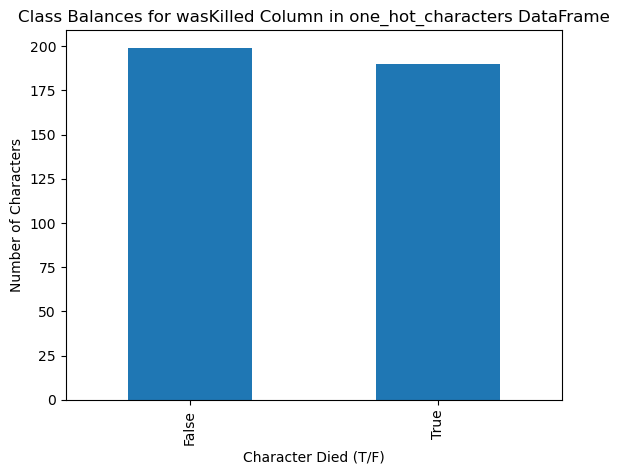

In [35]:
one_hot_characters['wasKilled'].value_counts().plot.bar()
plt.ylabel('Number of Characters')
plt.xlabel('Character Died (T/F)')
plt.title('Class Balances for wasKilled Column in one_hot_characters DataFrame')

I now wanted to add columns to the episode dataframe indicating whether a character dies in that episode, as well as how many deaths occur in the episode. I had to wait to do this until the Death in Scene column had been completed in the all_scenes dataframe, which is why this section is all the way down here.

In [36]:
deaths_per_episode = []

for season in episodes['seasonNum'].unique():
    
    # Each season can have a different number of episodes. Start iterating at episode 1, and go until one larger
    # than the upper bound of the number of episodes in that season (since the upper bound of range() is not
    # inclusive)
    for episode in range(1, np.max(episodes[episodes['seasonNum'] == season]['episodeNum'].unique()) + 1):
        
        # Add up all the deaths in the scene and append it to the deaths_per_episode list
        deaths_per_episode.append(np.sum(all_scenes[(all_scenes['Season Number'] == season) & (all_scenes['Episode Number'] == episode)]['Death in Scene']))

episodes['deathsPerEpisode'] = deaths_per_episode
episodes['episodeContainsDeath'] = episodes['deathsPerEpisode'] > 0
episodes.head(20)

,seasonNum,episodeNum,deathsPerEpisode,episodeContainsDeath
0,1,1,4,True
1,1,2,3,True
2,1,3,0,False
3,1,4,1,True
4,1,5,1,True
5,1,6,3,True
6,1,7,1,True
7,1,8,5,True
8,1,9,2,True
9,1,10,4,True


Make a graph of the number of deaths per episode to get an initial look at the deaths per episode data.

Text(0.5, 1.0, 'Deaths per Episode in Game of Thrones')

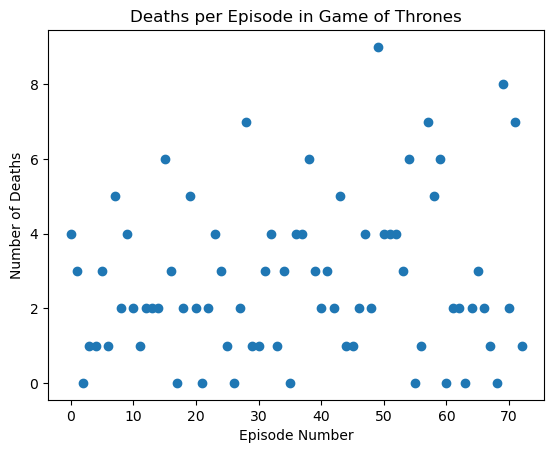

In [37]:
plt.scatter(episodes.index.values, episodes['deathsPerEpisode'])
plt.xlabel('Episode Number')
plt.ylabel('Number of Deaths')
plt.title('Deaths per Episode in Game of Thrones')

I thought about binning character screen time but decided against it, and just ended up standardizing numerical features for machine learning models where it made sense to do so. The bins were so heavily skewed right that it seemed better just to standardize the values.

In [455]:
bins = pd.cut(one_hot_characters['screenTime'], 8)
bins.value_counts()

(-41.104, 5138.0]     348
(5138.0, 10276.0]      22
(10276.0, 15414.0]      7
(15414.0, 20552.0]      5
(20552.0, 25690.0]      3
(35966.0, 41104.0]      2
(25690.0, 30828.0]      1
(30828.0, 35966.0]      1
Name: screenTime, dtype: int64

**<h2>Model Building/Tuning<h2>**

My ultimate goal is to see if I can predict whether an episode contains a character death (as well as how many), but my plan is to employ two sub-steps along the way. First, I wanted to see if I could train a model to predict whether a certain character would die throughout the show. Then, once I had done that, I would train another model to see if I could precict whether any character would die within a scene. Once I had my scene death predictions, I would combine them to get predictions for each episode (each episode is a sequence of scenes, and I can track how many deaths are in an episode across all of its scenes (if there are any in the first place)). Then I could compare how accurate my predictions were against the episode data.

Before I started training any models, however, I wanted to get a metric for a baseline classifier. In this case, I chose to label whether each character had died according to the most common category (interestingly enough, around 50% of the characters were killed/not killed). This matcdhes my class balances graph above.

In [229]:
one_hot_characters['wasKilled'].value_counts()
character_baseline = np.max(one_hot_characters['wasKilled'].value_counts())/ len(one_hot_characters)
character_baseline

0.5115681233933161

**<h4>Character Predictions<h4>**

So I started working with various machine learning algorithms to see if I could come up with a model that would predict whether or not a character died during the course of the show with reasonable accuracy

**<h4>Decison Trees<h4>**

I first started with a decision tree

In [115]:
# Prepare the X and y data sets and split into training and test sets
from sklearn.model_selection import train_test_split
y = one_hot_characters['wasKilled']
X = one_hot_characters.drop(['wasKilled'], axis=1)

# Split the data into training and test sets
X_train_tree, X_test_tree, y_train_tree, y_test_tree = train_test_split(X, y, test_size = .3, random_state = 1)

# Split training data into training set and validation set
X_train_tree, X_validate_tree, y_train_tree, y_validate_tree = train_test_split(X_train_tree, y_train_tree, test_size = .3, random_state = 1)


I experimented with several hyperparameters when training a decision tree model. I have made a bulletpoint list of each set of parameters (all iterations used the same random state for the train/test split):

1. Initial run - default settings (accuracy score: 0.6585)
2. Set 'criterion' equal to 'entropy' (accuracy score: 0.6098)
3. Kept criterion at 'entropy' and set 'splitter' to 'random' (accuracy score: 0.6829)
4. Set 'criterion' equal to 'log_loss' and set 'splitter' to best (accuracy score: 0.6220)
6. Set 'criterion' equal to 'log_loss' and set 'splitter' to 'random' (accuracy score: 0.6707)
6. Set 'criterion' equal to 'gini' and set 'splitter' to 'random' (accuracy score: 0.6585)

I decided not to tune any leaf, purity, or depth features, as I wanted the algorithm to have freedom to find the best splits as it saw fit. As a result, I achieved my best results, with an accuracy score of 0.6829, when using the 'entropy' criterion and a 'random' splitter. Note that for every run, I re-split the data and rebuilt the model.

In [116]:
# Import the dt classifier and fit the data to a model
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(criterion='entropy', splitter='random')
dfit = dt.fit(X_train_tree, y_train_tree)

2023/12/05 10:50:59 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'e66eed49f46d4722bbf397ada231e7e8', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2023/12/05 10:50:59 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/Users/johnbrassey/opt/anaconda3/lib/python3.9/site-packages/mlflow/data/pandas_dataset.py:134: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers

Test model on validation set

In [113]:
y_tree_validation_pred = dfit.predict(X_validate_tree)

In [114]:
from sklearn import metrics
metrics.accuracy_score(y_validate_tree, y_tree_validation_pred)

0.6585365853658537

Only run test predictions on using model parameters that worked best for the validation set. I ran the test set using the model with criteron = 'entropy' and splitter = 'random' and achieved an accuracy score on the test set of 0.7521

In [117]:
y__tree_pred = dfit.predict(X_test_tree)

In [118]:
metrics.accuracy_score(y_test_tree, y__tree_pred)

0.7521367521367521

See what the decision tree looks like. There actually weren't as many levels in the tree as I had expected, given that my data set had around 400 columns. On different runs, I ended up with very different tree structures.

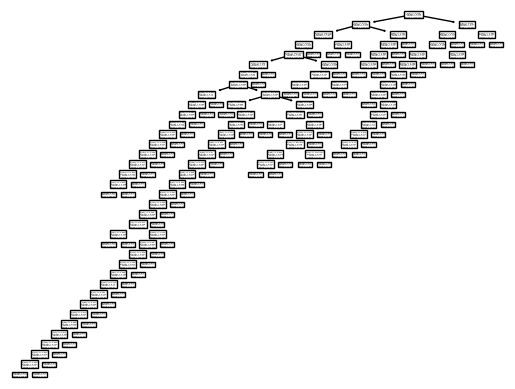

In [60]:
from sklearn.tree import plot_tree
_ = plot_tree(dfit)

**<h4>Random Forest<h4>**

Now try to fit a random forest and see if it performs better

In [144]:
# Split the data into training and test sets
X_train_forest, X_test_forest, y_train_forest, y_test_forest = train_test_split(X, y, test_size = .3, random_state = 2)

# Split training data into training set and validation set
X_train_forest, X_validate_forest, y_train_forest, y_validate_forest = train_test_split(X_train_tree, y_train_tree, test_size = .3, random_state = 2)


As with decision trees, I turned several different hyperparameters when training a random forest model. Each time I re-split the data (including training, validation, and test sets - the last of which I only used once, on the optimal model) and completely re-built the model. I have listed each iteration (along with its hyperparameters) below:

1. Initial run - Default parameters (accuracy score: 0.6666)
2. Set 'criterion' to 'entropy' (accuracy score: 0.6316)
3. Set 'criterion' to 'log_loss' (accuracy score: 0.6666)
4. Set 'criterion' to 'gini' and n_estimators to 150 (accuracy score: 0.6666)
5. Set 'criterion' to 'entropy' and n_estimators to 150 (accuracy score: 0.6842)
6. Set 'criterion' to 'log_loss' and n_estimators to 150 (accuracy score: 0.649)

I achieved the best results with the entropy criterion and number of trees set to 150. Those were the parameters of the model I used to test against the test set. On the run against the test set, I achieved an accuracy score of 0.8034

In [145]:
from sklearn.ensemble import RandomForestClassifier
forest = RandomForestClassifier(criterion='entropy', n_estimators=150);

Fit a model to the training data, but first only test each iteration on the validation set. Only test the model with the optimal hyperparameters with the test set.

In [146]:
rfit = forest.fit(X_train_forest, y_train_forest)

2023/12/05 13:50:47 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '5e514799e50c45989382ea00168dd390', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2023/12/05 13:50:47 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/Users/johnbrassey/opt/anaconda3/lib/python3.9/site-packages/mlflow/data/pandas_dataset.py:134: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers

In [142]:
y_forest_validate_pred = rfit.predict(X_validate_forest)
metrics.accuracy_score(y_validate_forest, y_forest_validate_pred)

0.6491228070175439

Only test the optimal model against the test set

In [147]:
y_forest_pred = rfit.predict(X_test_forest)
metrics.accuracy_score(y_test_forest, y_forest_pred)

0.8034188034188035

**<h4>SVC<h4>**

Now try SVCs

Take a look at the correlation matrix before fitting an SVC model

In [152]:
one_hot_characters.corr().head(40)

,wasKilled,hasKilledOthers,notHuman,wasServed,hasSiblings,isYoungVersion,hasChildren,childOfNamedCharacter,isMarried,hasServed,...,houseName_Greyjoy,houseName_Lannister,houseName_Martell,houseName_Mormont,houseName_Stark,houseName_Targaryen,houseName_Tarly,houseName_Tully,houseName_Tyrell,houseName_Umber
wasKilled,1.000000,0.304426,0.054874,0.053337,0.214587,-0.132272,0.156505,0.185287,0.163969,0.044699,...,0.025469,0.101246,0.112061,0.090223,0.039664,0.123101,-0.049606,-0.086142,0.104316,0.051956
hasKilledOthers,0.304426,1.000000,0.175536,0.137277,0.226172,-0.068878,0.181909,0.208054,0.266872,0.129328,...,0.054868,0.037916,0.060713,0.100555,0.075462,0.129928,-0.025832,-0.044857,0.011183,-0.025832
notHuman,0.054874,0.175536,1.000000,-0.015687,0.375282,-0.020833,-0.049895,-0.063110,-0.054253,-0.030820,...,-0.017561,-0.024998,-0.022300,-0.013567,0.417235,0.269229,-0.007813,-0.013567,-0.015687,-0.007813
wasServed,0.053337,0.137277,-0.015687,1.000000,0.103379,-0.013798,0.227532,0.030790,0.126602,0.111932,...,-0.011631,0.144459,-0.014770,-0.008986,-0.024349,0.276568,-0.005175,-0.008986,-0.010390,-0.005175
hasSiblings,0.214587,0.226172,0.375282,0.103379,1.000000,-0.055512,0.291382,0.499356,0.392575,-0.044094,...,0.278258,0.257289,0.095369,-0.036153,0.420504,0.308003,0.123798,0.131268,0.103379,-0.020819
isYoungVersion,-0.132272,-0.068878,-0.020833,-0.013798,-0.055512,1.000000,-0.043888,-0.055512,-0.047721,-0.027110,...,-0.015447,0.100205,-0.019616,-0.011934,0.309954,-0.024151,-0.006872,-0.011934,-0.013798,-0.006872
hasChildren,0.156505,0.181909,-0.049895,0.227532,0.291382,-0.043888,1.000000,0.116656,0.472552,-0.019420,...,0.040795,0.168808,0.199982,0.071584,0.077648,0.144868,-0.016459,-0.028582,0.140672,-0.016459
childOfNamedCharacter,0.185287,0.208054,-0.063110,0.030790,0.499356,-0.055512,0.116656,1.000000,0.322513,-0.006062,...,0.083227,0.211017,0.146966,0.047558,0.226079,0.180948,0.123798,-0.036153,0.103379,-0.020819
isMarried,0.163969,0.266872,-0.054253,0.126602,0.392575,-0.047721,0.472552,0.322513,1.000000,-0.028021,...,-0.040227,0.046343,0.179979,-0.031079,0.097177,0.174180,-0.017897,0.062639,0.045334,-0.017897
hasServed,0.044699,0.129328,-0.030820,0.111932,-0.044094,-0.027110,-0.019420,-0.006062,-0.028021,1.000000,...,-0.022852,0.051832,-0.029020,0.134965,-0.047840,-0.035730,-0.010167,-0.017655,-0.020413,-0.010167


In [153]:
one_hot_characters.corr().tail(40)

,wasKilled,hasKilledOthers,notHuman,wasServed,hasSiblings,isYoungVersion,hasChildren,childOfNamedCharacter,isMarried,hasServed,...,houseName_Greyjoy,houseName_Lannister,houseName_Martell,houseName_Mormont,houseName_Stark,houseName_Targaryen,houseName_Tarly,houseName_Tully,houseName_Tyrell,houseName_Umber
characterName_Wedding Band,-0.049606,-0.025832,-0.007813,-0.005175,-0.020819,-0.006872,-0.016459,-0.020819,-0.017897,-0.010167,...,-0.005793,-0.008246,-0.007356,-0.004476,-0.012127,-0.009057,-0.002577,-0.004476,-0.005175,-0.002577
characterName_White Walker,0.031434,0.027849,-0.013567,-0.008986,-0.036153,-0.011934,-0.028582,-0.036153,-0.031079,-0.017655,...,-0.010060,-0.014320,-0.012775,-0.007772,-0.021060,-0.015728,-0.004476,-0.007772,-0.008986,-0.004476
characterName_White Walker #2,-0.049606,-0.025832,-0.007813,-0.005175,-0.020819,-0.006872,-0.016459,-0.020819,-0.017897,-0.010167,...,-0.005793,-0.008246,-0.007356,-0.004476,-0.012127,-0.009057,-0.002577,-0.004476,-0.005175,-0.002577
characterName_Wight Wildling Girl,-0.049606,-0.025832,-0.007813,-0.005175,-0.020819,-0.006872,-0.016459,-0.020819,-0.017897,-0.010167,...,-0.005793,-0.008246,-0.007356,-0.004476,-0.012127,-0.009057,-0.002577,-0.004476,-0.005175,-0.002577
characterName_Wildling Rioter,-0.049606,-0.025832,-0.007813,-0.005175,-0.020819,-0.006872,-0.016459,-0.020819,-0.017897,-0.010167,...,-0.005793,-0.008246,-0.007356,-0.004476,-0.012127,-0.009057,-0.002577,-0.004476,-0.005175,-0.002577
characterName_Will,0.051956,-0.025832,-0.007813,-0.005175,-0.020819,-0.006872,-0.016459,-0.020819,-0.017897,-0.010167,...,-0.005793,-0.008246,-0.007356,-0.004476,-0.012127,-0.009057,-0.002577,-0.004476,-0.005175,-0.002577
characterName_Willem Lannister,0.051956,-0.025832,-0.007813,-0.005175,0.123798,-0.006872,-0.016459,0.123798,-0.017897,-0.010167,...,-0.005793,0.312539,-0.007356,-0.004476,-0.012127,-0.009057,-0.002577,-0.004476,-0.005175,-0.002577
characterName_Willis Wode,0.051956,-0.025832,-0.007813,-0.005175,-0.020819,-0.006872,-0.016459,-0.020819,-0.017897,-0.010167,...,-0.005793,-0.008246,-0.007356,-0.004476,-0.012127,-0.009057,-0.002577,-0.004476,-0.005175,-0.002577
characterName_Wine Merchant,-0.049606,-0.025832,-0.007813,-0.005175,-0.020819,-0.006872,-0.016459,-0.020819,-0.017897,-0.010167,...,-0.005793,-0.008246,-0.007356,-0.004476,-0.012127,-0.009057,-0.002577,-0.004476,-0.005175,-0.002577
characterName_Winterfell Shepherd,-0.049606,-0.025832,-0.007813,-0.005175,-0.020819,-0.006872,-0.016459,-0.020819,-0.017897,-0.010167,...,-0.005793,-0.008246,-0.007356,-0.004476,-0.012127,-0.009057,-0.002577,-0.004476,-0.005175,-0.002577


Solely based on the eyeball test, I wasn't able to find any features in either the head or the tail of the correlation matrix that appeared strongly correlated. That is encouraging, as it seems to validate (at least on the surface), that each feature in the DataFrame might be providing unique, valuable information to the model.

In [155]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

I attempted to perform a grid search to find the optimal parameters for an SVC model. However, the search was simply taking too long, so I decided to manually test hyperparameters in order to find the best fit that I could.

In [ ]:
# parameters = {'kernel':('linear', 'rbf', 'poly'), 'C':[1, 10], 'coef0':[0, 10], 'degree':[2, 8]}
# svc = SVC()
# clf = GridSearchCV(svc, parameters)
# clf.fit(X_train_svc, y_train_svc)
# GridSearchCV(estimator=SVC(), param_grid=parameters)
# optimal_parameters = sorted(clf.cv_results_.keys())
# optimal_parameters


In [196]:
# Split the data into training and test sets
X_train_svc, X_test_svc, y_train_svc, y_test_svc = train_test_split(X, y, test_size = .3, random_state = 3)

# Split training data into training set and validation set
X_train_svc, X_validate_svc, y_train_svc, y_validate_svc = train_test_split(X_train_svc, y_train_svc, test_size = .3, random_state = 3)


Below is a list of the sets of hyperparameters I tested with, along with their accuracy scores on the validation set:

1. Initial run - kernel - rbf, C - 10, coef0- 1 (accuracy score: 0.5976)
2. kernel = rbf, C = 1, coef0 = 1 (accuracy score: 0.6098)
3. kernel = rbf, C = 2, coef0 = 1 (accuracy score: 0.5976)
4. kernel = rbf, C = 3, coef0 = 1 (accuracy score: 0.5976)
5. kernel = poly, C = 10, coef0 = 1, degree = 3 (accuracy score: 0.6707)
6. kernel = poly, C = 10, coef0 = 1, degree = 4 (accuracy score: 0.6707)
7. kernel = poly, C = 10, coef0 = 1, degree = 6 (accuracy score: 0.6707)
8. kernel = poly, C = 1, coef0 = 1, degree = 3 (accuracy score: 0.6707)
9. kernel = poly, C = 10, coef0 = 0.1, degree = 3 (accuracy score: 0.5854)
10. kernel = poly, C = 10, coef0 = 5, degree = 3 (accuracy score: 0.6707)
11. kernel = sigmoid, C = 10, coef0 = 1, (accuracy score: 0.6707)
12. kernel = sigmoid, C = 1, coef0 = 1, (accuracy score: 0.3902)

Based on these runs, I have decided to use a polynomial kernal with degree 3, C = 10, and coef0 = 1 for the optimal model. My final model, run against the test set, achieved an accuracy score of 0.6666

In [197]:
# Fit an SVC model to the training data
svc = Pipeline([("scalar", StandardScaler()), ("svc_clf", SVC(kernel="poly", C=10, coef0=1, degree=3, random_state=1))])

svc_fit = svc.fit(X_train_svc, y_train_svc)

2023/12/06 09:54:29 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '25d0c7b6646e4988ba32c1f7ea6aae9f', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2023/12/06 09:54:29 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/Users/johnbrassey/opt/anaconda3/lib/python3.9/site-packages/mlflow/data/pandas_dataset.py:134: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers

Make predictions and get the accuracy score for the validation data

In [198]:
svc_validate_predict = svc_fit.predict(X_validate_svc)
metrics.accuracy_score(y_validate_svc, svc_validate_predict)

0.6707317073170732

Only test the test data against the best model

In [199]:
svc_predict = svc_fit.predict(X_test_svc)
metrics.accuracy_score(y_test_svc, svc_predict)

0.6666666666666666

**<h4>Naive Bayes<h4>**

In [217]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline

# Split the data into training and test sets
X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(X, y, test_size = .3, random_state = 4)

# Split training data into training set and validation set
# X_train_nb, X_validate_nb, y_train_nb, y_validate_nb = train_test_split(X_train_svc, y_train_svc, test_size = .3, random_state = 4)

In [218]:
nb = make_pipeline(MultinomialNB())
nb_fit = nb.fit(X_train_nb, y_train_nb)

2023/12/06 10:18:13 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '8889f1491f3f4de8a6de30d033e441e4', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2023/12/06 10:18:13 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/Users/johnbrassey/opt/anaconda3/lib/python3.9/site-packages/mlflow/data/pandas_dataset.py:134: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers

In [219]:
nb_predict = nb_fit.predict(X_test_nb)
metrics.accuracy_score(y_test_nb, nb_predict)

0.7521367521367521

**<h4>Logistic Regression<h4>**

In [223]:
from sklearn.linear_model import LogisticRegression
lgr = LogisticRegression(max_iter=1000)

# Split the data into training and test sets
X_train_lg, X_test_lg, y_train_lg, y_test_lg = train_test_split(X, y, test_size = .3, random_state = 4)

lgr.fit(X_train_lg, y_train_lg)

2023/12/06 10:30:24 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'e2eca2b9d59d4f6f954512ad63e9a3de', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2023/12/06 10:30:24 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/Users/johnbrassey/opt/anaconda3/lib/python3.9/site-packages/mlflow/data/pandas_dataset.py:134: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers

LogisticRegression(max_iter=1000)

In [224]:
y_pred_lg = lgr.predict(X_test_lg)
metrics.accuracy_score(y_test_lg, y_pred_lg)

0.6666666666666666

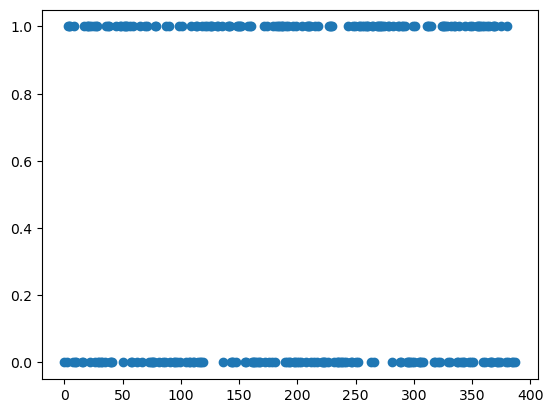

In [228]:
plt.scatter(X_train_lg.index.values, y_train_lg)
#plt.plot(X_train_lg.index.values, lgr.predict(X_train_lg))

Looking at this graph, this dataset seems like it would be difficult for a logistic model to predict, given how much overlap there is between data (i.e. much of the data is almost right on top of each other).

Now that predictions for the one_hot_characters dataFrame have been made, I wanted to add back in the character names to be able to easily see which character was which

In [232]:
one_hot_characters['characterName'] = characters['characterName']
one_hot_characters

,wasKilled,hasKilledOthers,notHuman,wasServed,hasSiblings,isYoungVersion,hasChildren,childOfNamedCharacter,isMarried,hasServed,...,houseName_Lannister,houseName_Martell,houseName_Mormont,houseName_Stark,houseName_Targaryen,houseName_Tarly,houseName_Tully,houseName_Tyrell,houseName_Umber,characterName
0,False,False,False,False,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,Addam Marbrand
1,True,False,False,False,True,False,False,True,False,False,...,0,0,0,0,1,0,0,0,0,Aegon Targaryen
2,False,False,False,False,True,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,Aeron Greyjoy
3,True,True,False,True,True,False,True,False,True,False,...,0,0,0,0,1,0,0,0,0,Aerys II Targaryen
4,True,False,False,False,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,Akho
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
384,False,False,False,False,False,True,False,False,False,False,...,0,0,0,0,0,0,0,0,0,Young Nan
385,False,False,False,False,False,True,False,False,False,False,...,0,0,0,1,0,0,0,0,0,Young Ned
386,False,False,False,False,False,True,False,False,False,False,...,0,0,0,1,0,0,0,0,0,Young Ned Stark
387,False,False,False,False,False,True,False,False,False,False,...,0,0,0,0,0,0,0,0,0,Young Rodrik Cassel


**<h4>Scene Predictions<h4>**

Let's briefly look at the class balances on the classifier column 'deathInScene'

Text(0.5, 1.0, 'Class Balances for deathInScene Column in one_hot_scenes DataFrame')

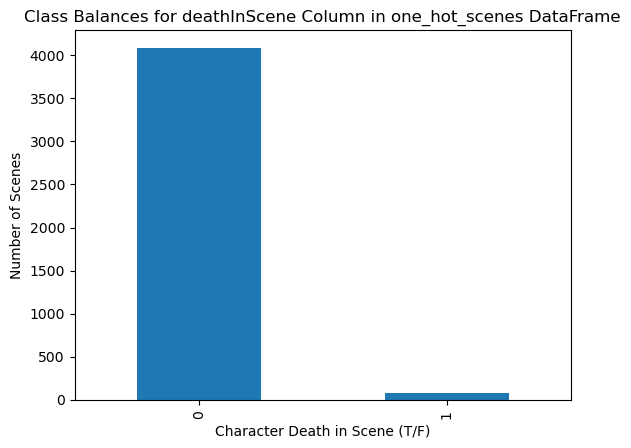

In [406]:
one_hot_scenes['deathInScene'].value_counts().plot.bar()
plt.ylabel('Number of Scenes')
plt.xlabel('Character Death in Scene (T/F)')
plt.title('Class Balances for deathInScene Column in one_hot_scenes DataFrame')

The classes are clearly very imbalanced, which may make prediction difficult, and will magnify false negatives (scenes where a death occured which the model labels as a death having not occured).

Before I created models to determine whether a scene contained a character death, I wanted to add a few more pieces of information. First, I couldn't use the current list of characters in each scene when training machine learning models on the dataframe, so instead, for each character, I created a binary column to indicate whether a scene contained that character.

In [261]:
# for character in one_hot_characters['characterName']:
#     print(character.replace(" ", ""))

In [278]:
columns = []

for character in one_hot_characters['characterName']:
    
    # Create the new column name for each new column with the following format :'containsJonSnow' with no whitespace
    characterName = "".join(character.split())
    columnName = "contains" + characterName
    
    # Create new column and append it to columns
    newColumn = pd.Series([character in scene_characters for scene_characters in one_hot_scenes['characters']], name=columnName)
    columns.append(newColumn)

# Add new columns to one_hot_scenes
for column in columns:
    pd.concat([one_hot_scenes, column], axis=1)

one_hot_scenes

,sceneStart,sceneEnd,Season Number,Episode Number,sceneDuration,totalCharacters,location_Astapor,location_Braavos,location_Dorne,location_Meereen,...,containsYohn Royce,containsYoren,containsYoung Benjen Stark,containsYoung Cersei Lannister,containsYoung Lyanna Stark,containsYoung Nan,containsYoung Ned,containsYoung Ned Stark,containsYoung Rodrik Cassel,containsZanrush
0,40.0,105.0,1.0,1.0,65.0,3,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
1,105.0,204.0,1.0,1.0,99.0,3,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
2,204.0,211.0,1.0,1.0,7.0,2,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
3,211.0,218.0,1.0,1.0,7.0,1,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
4,218.0,224.0,1.0,1.0,6.0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4160,4644.0,4675.0,8.0,6.0,31.0,1,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
4161,4675.0,4691.0,8.0,6.0,16.0,1,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
4162,4691.0,4700.0,8.0,6.0,9.0,3,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
4163,4700.0,4780.0,8.0,6.0,80.0,3,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False


Check a few of the columns to see if the scenes contain the character(s) I expect. I cannot figure out why pandas is adding spaces to the new column names. I have checked many times, and the column names should not (and do not, within each Series) have any spaces in them.

In [269]:
one_hot_scenes['containsWill'].head(20)

0      True
1      True
2      True
3      True
4     False
5      True
6      True
7     False
8      True
9     False
10     True
11     True
12     True
13     True
14     True
15    False
16    False
17    False
18    False
19    False
Name: containsWill, dtype: bool

In [255]:
one_hot_scenes['containsJon Snow'].head(20)

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13     True
14     True
15     True
16    False
17    False
18    False
19     True
Name: containsJon Snow, dtype: bool

Remove the characters column from one_hot_scenes

In [282]:
# one_hot_scenes = one_hot_scenes.drop(['characters'], axis=1)

In [283]:
one_hot_scenes

,sceneStart,sceneEnd,Season Number,Episode Number,sceneDuration,totalCharacters,location_Astapor,location_Braavos,location_Dorne,location_Meereen,...,containsYohn Royce,containsYoren,containsYoung Benjen Stark,containsYoung Cersei Lannister,containsYoung Lyanna Stark,containsYoung Nan,containsYoung Ned,containsYoung Ned Stark,containsYoung Rodrik Cassel,containsZanrush
0,40.0,105.0,1.0,1.0,65.0,3,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
1,105.0,204.0,1.0,1.0,99.0,3,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
2,204.0,211.0,1.0,1.0,7.0,2,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
3,211.0,218.0,1.0,1.0,7.0,1,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
4,218.0,224.0,1.0,1.0,6.0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4160,4644.0,4675.0,8.0,6.0,31.0,1,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
4161,4675.0,4691.0,8.0,6.0,16.0,1,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
4162,4691.0,4700.0,8.0,6.0,9.0,3,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
4163,4700.0,4780.0,8.0,6.0,80.0,3,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False


Now that I have all the features that I want in one_hot_scenes, I will start training machine learning models. However, I realized just before I started training that when I one_hot_encoded the dataframe, it turned the "Death in Scene" column into two columns (one for true and one for false). I needed only one column, so I had to quickly fix that issue.

In [291]:
one_hot_scenes['deathInScene'] = one_hot_scenes['Death in Scene_True']
one_hot_scenes = one_hot_scenes.copy()
one_hot_scenes = one_hot_scenes.drop(['Death in Scene_False', 'Death in Scene_True'], axis=1)
one_hot_scenes

,sceneStart,sceneEnd,Season Number,Episode Number,sceneDuration,totalCharacters,location_Astapor,location_Braavos,location_Dorne,location_Meereen,...,containsYoren,containsYoung Benjen Stark,containsYoung Cersei Lannister,containsYoung Lyanna Stark,containsYoung Nan,containsYoung Ned,containsYoung Ned Stark,containsYoung Rodrik Cassel,containsZanrush,deathInScene
0,40.0,105.0,1.0,1.0,65.0,3,0,0,0,0,...,False,False,False,False,False,False,False,False,False,0
1,105.0,204.0,1.0,1.0,99.0,3,0,0,0,0,...,False,False,False,False,False,False,False,False,False,0
2,204.0,211.0,1.0,1.0,7.0,2,0,0,0,0,...,False,False,False,False,False,False,False,False,False,0
3,211.0,218.0,1.0,1.0,7.0,1,0,0,0,0,...,False,False,False,False,False,False,False,False,False,0
4,218.0,224.0,1.0,1.0,6.0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4160,4644.0,4675.0,8.0,6.0,31.0,1,0,0,0,0,...,False,False,False,False,False,False,False,False,False,0
4161,4675.0,4691.0,8.0,6.0,16.0,1,0,0,0,0,...,False,False,False,False,False,False,False,False,False,0
4162,4691.0,4700.0,8.0,6.0,9.0,3,0,0,0,0,...,False,False,False,False,False,False,False,False,False,0
4163,4700.0,4780.0,8.0,6.0,80.0,3,0,0,0,0,...,False,False,False,False,False,False,False,False,False,0


First I need a baseline classifier for one_hot_scenes. Since most of the scenes do not contain a character death, I am not surprised that the baseline classifier, which simply labels all samples according to the majority class, is above 0.95

In [336]:
one_hot_scenes['deathInScene'].value_counts()
scenes_baseline = np.max(one_hot_scenes['deathInScene'].value_counts())/ len(one_hot_scenes)
scenes_baseline

0.9517406962785114

**<h4>Decision Trees<h4>**

I first attemped to predict whether there was a death in each scene using decision trees

In [2]:
# Prepare the X and y data sets and split into training and test sets
from sklearn.model_selection import train_test_split
y = one_hot_scenes['deathInScene']
X = one_hot_scenes.drop(['deathInScene'], axis=1)

# Split the data into training and test sets
X_train_tree, X_test_tree, y_train_tree, y_test_tree = train_test_split(X, y, test_size = .3, random_state = 1)

# Split training data into training set and validation set
X_train_tree, X_validate_tree, y_train_tree, y_validate_tree = train_test_split(X_train_tree, y_train_tree, test_size = .3, random_state = 1)


NameError: name 'one_hot_scenes' is not defined

I experimented with several hyperparameters when training a decision tree model. I have made a bulletpoint list of each set of parameters (all iterations used the same random state for the train/test split):

1. Initial run - default settings (accuracy score: 0.9177)
2. Set 'criterion' equal to 'entropy' (accuracy score: 0.9097)
3. Kept criterion at 'entropy' and set 'splitter' to 'random' (accuracy score: 0.9086)
4. Set 'criterion' equal to 'log_loss' and set 'splitter' to best (accuracy score: 0.9131)
6. Set 'criterion' equal to 'log_loss' and set 'splitter' to 'random' (accuracy score: 0.9063)
6. Set 'criterion' equal to 'gini' and set 'splitter' to 'random' (accuracy score: 0.912)

I decided not to tune any leaf, purity, or depth features, as I wanted the algorithm to have freedom to find the best splits as it saw fit. As a result, I achieved my best results, with an accuracy score of 0.9177, when using the 'gini' criterion and the 'best' splitter. Note that for every run, I re-split the data and rebuilt the model. I forgot to balance the classes when I initially trained the model. When I balanced the class weights, I achieved notably better results against the validation set (I did not re-test the test set, since I had previously used it).

In [408]:
dt = DecisionTreeClassifier(criterion='gini', splitter='random', class_weight='balanced')
dfit = dt.fit(X_train_tree, y_train_tree)

2023/12/07 01:20:44 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'fe60939ba0ae4fbdae96bf9a50146e87', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2023/12/07 01:20:44 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/Users/johnbrassey/opt/anaconda3/lib/python3.9/site-packages/mlflow/data/pandas_dataset.py:134: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers

Test the model on the validation set

In [409]:
y_tree_validation_pred = dfit.predict(X_validate_tree)
metrics.accuracy_score(y_validate_tree, y_tree_validation_pred)

0.9611428571428572

Only run test predictions on using model parameters that worked best for the validation set. I ran the test set using the model with criteron = 'gini' and splitter = 'best' and achieved an accuracy score on the test set of 0.9184

In [313]:
y__tree_pred = dfit.predict(X_test_tree)
metrics.accuracy_score(y_test_tree, y__tree_pred)

0.9184

Although these accuracy values seem high, when compared to the baseline classifier, decision trees actually perform worse.

**<h4>Random Forest<h4>**

In [410]:
# Split the data into training and test sets
X_train_forest, X_test_forest, y_train_forest, y_test_forest = train_test_split(X, y, test_size = .3, random_state = 2)

# Split training data into training set and validation set
X_train_forest, X_validate_forest, y_train_forest, y_validate_forest = train_test_split(X_train_tree, y_train_tree, test_size = .3, random_state = 2)


As with decision trees, I turned several different hyperparameters when training a random forest model. Each time I re-split the data (including training, validation, and test sets - the last of which I only used once, on the optimal model) and completely re-built the model. I have listed each iteration (along with its hyperparameters) below:

1. Initial run - Default parameters (accuracy score: 0.9641)
2. Set 'criterion' to 'entropy' (accuracy score: 0.9641)
3. Set 'criterion' to 'log_loss' (accuracy score: 0.9641)
4. Set 'criterion' to 'gini' and n_estimators to 150 (accuracy score: 0.9624)
5. Set 'criterion' to 'entropy' and n_estimators to 150 (accuracy score: 0.9624)
6. Set 'criterion' to 'log_loss' and n_estimators to 150 (accuracy score: 0.9641)

I achieved the best results with the gini criterion and number of trees set to 100. Those were the parameters of the model I used to test against the test set. On the run against the test set, I achieved an accuracy score of 0.9648. Once again, I forgot to balance the classes the first time around. When balancing the classes, I achieved results near 1 (0.9983) on the validation set.

In [412]:
forest = RandomForestClassifier(class_weight='balanced')
rfit = forest.fit(X_train_forest, y_train_forest)

2023/12/07 01:22:23 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '4c1c69cfdd5945929577bfaa4e5fcb51', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2023/12/07 01:22:23 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/Users/johnbrassey/opt/anaconda3/lib/python3.9/site-packages/mlflow/data/pandas_dataset.py:134: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers

Test the model on the validation

In [413]:
y_forest_validate_pred = rfit.predict(X_validate_forest)
metrics.accuracy_score(y_validate_forest, y_forest_validate_pred)

0.9983660130718954

Only test the optimal model on the test set

In [335]:
y_forest_pred = rfit.predict(X_test_forest)
metrics.accuracy_score(y_test_forest, y_forest_pred)

0.9648

The random forest model actually performed slightly better than the baseline classifier. Since the baseline classifier was already above 95%, I'm happy with even a 0.01 increase in performance.

**<h4>SVC<h4>**

Take a look at the correlation matrix head and tail before training the model

In [337]:
one_hot_scenes.corr().head(40)

,sceneStart,sceneEnd,Season Number,Episode Number,sceneDuration,totalCharacters,location_Astapor,location_Braavos,location_Dorne,location_Meereen,...,containsYoren,containsYoung Benjen Stark,containsYoung Cersei Lannister,containsYoung Lyanna Stark,containsYoung Nan,containsYoung Ned,containsYoung Ned Stark,containsYoung Rodrik Cassel,containsZanrush,deathInScene
sceneStart,1.000000,0.998209,0.210601,0.019847,-0.105532,-0.049304,0.042932,-0.048210,0.006508,-0.013293,...,0.002031,-0.031630,-0.030650,-0.037106,0.025988,NaN,-0.002283,-0.005502,0.004091,0.058897
sceneEnd,0.998209,1.000000,0.195515,0.020507,-0.045854,-0.032357,0.043433,-0.048239,0.006733,-0.011797,...,0.005148,-0.032708,-0.029424,-0.037988,0.024734,NaN,-0.002818,-0.006429,0.006027,0.065072
Season Number,0.210601,0.195515,1.000000,-0.257466,-0.266723,-0.098676,-0.062079,0.028605,0.013155,-0.009441,...,-0.101654,0.014826,-0.000280,0.011482,0.014826,NaN,0.026663,0.013259,0.009374,-0.064561
Episode Number,0.019847,0.020507,-0.257466,1.000000,0.009475,-0.038933,-0.054073,0.036971,0.034973,-0.003501,...,0.015099,-0.032630,-0.033311,-0.031094,-0.010063,NaN,-0.004256,-0.019090,-0.017459,0.050345
sceneDuration,-0.105532,-0.045854,-0.266723,0.009475,1.000000,0.285447,0.005073,0.003168,0.003249,0.025875,...,0.051653,-0.015524,0.022696,-0.011858,-0.022810,NaN,-0.008721,-0.014993,0.031875,0.098184
totalCharacters,-0.049304,-0.032357,-0.098676,-0.038933,0.285447,1.000000,0.020419,0.006850,0.040838,0.023759,...,0.046964,0.042615,-0.003807,0.039089,0.027877,NaN,0.051636,0.037453,0.005511,0.102580
location_Astapor,0.042932,0.043433,-0.062079,-0.054073,0.005073,0.020419,1.000000,-0.011061,-0.007657,-0.014934,...,-0.004314,-0.002408,-0.001523,-0.001865,-0.002408,NaN,-0.004034,-0.002154,-0.001523,0.000564
location_Braavos,-0.048210,-0.048239,0.028605,0.036971,0.003168,0.006850,-0.011061,1.000000,-0.017553,-0.034234,...,-0.009889,-0.005521,-0.003490,-0.004275,-0.005521,NaN,-0.009248,-0.004937,-0.003490,0.007425
location_Dorne,0.006508,0.006733,0.013155,0.034973,0.003249,0.040838,-0.007657,-0.017553,1.000000,-0.023698,...,-0.006845,-0.003822,-0.002416,-0.002959,-0.003822,NaN,0.260225,-0.003418,-0.002416,0.047186
location_Meereen,-0.013293,-0.011797,-0.009441,-0.003501,0.025875,0.023759,-0.014934,-0.034234,-0.023698,1.000000,...,-0.013351,-0.007453,-0.004712,-0.005772,-0.007453,NaN,-0.012485,-0.006666,0.101953,0.011560


In [338]:
one_hot_scenes.corr().tail(40)

,sceneStart,sceneEnd,Season Number,Episode Number,sceneDuration,totalCharacters,location_Astapor,location_Braavos,location_Dorne,location_Meereen,...,containsYoren,containsYoung Benjen Stark,containsYoung Cersei Lannister,containsYoung Lyanna Stark,containsYoung Nan,containsYoung Ned,containsYoung Ned Stark,containsYoung Rodrik Cassel,containsZanrush,deathInScene
containsTyene Sand,0.014039,0.014320,0.031909,-0.007001,0.003594,0.057830,-0.005611,-0.012863,0.458096,-0.017366,...,-0.005016,-0.002800,-0.001771,-0.002169,-0.002800,NaN,-0.004691,-0.002504,-0.001771,0.037649
containsTyrion Lannister,-0.019604,-0.013105,0.014497,-0.028404,0.109518,0.273747,-0.026924,-0.061721,-0.042725,0.100440,...,0.010484,-0.013438,-0.008496,-0.010406,-0.013438,NaN,-0.022510,-0.012018,0.056549,-0.044061
containsTywin Lannister,-0.043702,-0.038744,-0.108972,-0.000855,0.085726,0.174077,-0.010382,-0.023799,-0.016474,-0.032131,...,-0.009281,-0.005181,-0.003276,-0.004013,-0.005181,NaN,-0.008680,-0.004634,-0.003276,-0.003001
containsVala,0.003532,0.004692,0.003017,-0.024696,0.019002,-0.011975,-0.002154,-0.004937,-0.003418,0.144218,...,-0.001925,-0.001075,-0.000680,-0.000832,-0.001075,NaN,-0.001801,-0.000961,-0.000680,0.101521
containsVardis Egen,-0.001656,0.002334,-0.055021,0.003334,0.066454,0.044043,-0.002154,-0.004937,-0.003418,-0.006666,...,-0.001925,-0.001075,-0.000680,-0.000832,-0.001075,NaN,-0.001801,-0.000961,-0.000680,0.029186
containsVarly,0.017032,0.016585,-0.027501,0.010073,-0.008733,0.007191,-0.001076,-0.002468,-0.001708,-0.003332,...,-0.000962,-0.000537,-0.000340,-0.000416,-0.000537,NaN,-0.000900,-0.000480,-0.000340,0.068820
containsViserion,0.116707,0.116411,0.025274,-0.001601,-0.013764,0.109993,0.017683,-0.020970,-0.014516,0.061951,...,-0.008178,-0.004566,-0.002886,-0.003536,-0.004566,NaN,-0.007648,-0.004083,-0.002886,0.022273
containsViserys Targaryen,-0.010846,-0.004695,-0.095391,-0.037957,0.103069,0.051602,-0.003734,-0.008560,-0.005925,-0.011556,...,-0.003338,-0.001864,-0.001178,-0.001443,-0.001864,NaN,-0.003122,-0.001667,-0.001178,0.008797
containsWalda Bolton,-0.001455,0.000464,-0.000486,-0.018808,0.032003,0.031080,-0.002638,-0.006048,-0.004187,-0.008166,...,-0.002359,-0.001317,-0.000833,-0.001020,-0.001317,NaN,-0.002206,-0.001178,-0.000833,0.020985
containsWalder Frey,0.007295,0.008498,-0.039328,0.087602,0.019450,0.059843,-0.005398,-0.012374,-0.008566,-0.016706,...,-0.004826,-0.002694,-0.001703,-0.002086,-0.002694,NaN,-0.004513,-0.002409,-0.001703,0.055020


Based on the eyeball test, I didn't notice any overly high correlations between any of the features

In [414]:
# Split the data into training and test sets
X_train_svc, X_test_svc, y_train_svc, y_test_svc = train_test_split(X, y, test_size = .3, random_state = 3)

# Split training data into training set and validation set
X_train_svc, X_validate_svc, y_train_svc, y_validate_svc = train_test_split(X_train_svc, y_train_svc, test_size = .3, random_state = 3)


Below is a list of the sets of hyperparameters I tested with, along with their accuracy scores on the validation set:

1. Initial run - kernel - rbf, C - 10, coef0- 1 (accuracy score: 0.9349)
2. kernel = rbf, C = 1, coef0 = 1 (accuracy score: 0.944)
3. kernel = rbf, C = 2, coef0 = 1 (accuracy score: 0.9406)
4. kernel = rbf, C = 3, coef0 = 1 (accuracy score: 0.9392)
5. kernel = poly, C = 10, coef0 = 1, degree = 3 (accuracy score: 0.9314)
6. kernel = poly, C = 10, coef0 = 1, degree = 4 (accuracy score: 0.9257)
7. kernel = poly, C = 10, coef0 = 1, degree = 6 (accuracy score: 0.9223)
8. kernel = poly, C = 1, coef0 = 1, degree = 3 (accuracy score: 0.936)
9. kernel = poly, C = 10, coef0 = 0.1, degree = 3 (accuracy score: 0.9337)
10. kernel = poly, C = 10, coef0 = 5, degree = 3 (accuracy score: 0.9177)
11. kernel = sigmoid, C = 10, coef0 = 1, (accuracy score: 0.9406)
12. kernel = sigmoid, C = 1, coef0 = 1, (accuracy score: 0.9451)

Based on these runs, I have decided to use a sigmoid kernal with C = 1, and coef0 = 1 for the optimal model. My final model, run against the test set, achieved an accuracy score of 0.952, which was slightly higher than the baseline classifier

In [417]:
# Fit an SVC model to the training data
svc = Pipeline([("scalar", StandardScaler()), ("svc_clf", SVC(kernel="sigmoid", C=1, coef0=1, degree=3, random_state=1))])

svc_fit = svc.fit(X_train_svc, y_train_svc)

2023/12/07 01:23:37 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '41e17b5ff7634b3b9eb4a30935b12739', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2023/12/07 01:23:37 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/Users/johnbrassey/opt/anaconda3/lib/python3.9/site-packages/mlflow/data/pandas_dataset.py:134: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers

In [418]:
svc_validate_predict = svc_fit.predict(X_validate_svc)
metrics.accuracy_score(y_validate_svc, svc_validate_predict)

0.9782857142857143

Only test the optimal model against the test set

In [378]:
svc_predict = svc_fit.predict(X_test_svc)
metrics.accuracy_score(y_test_svc, svc_predict)

0.952

**<h4>Naive Bayes<h4>**

In [3]:
# Split the data into training and test sets
X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(X, y, test_size = .3, random_state = 4, class_weight='balanced')

NameError: name 'X' is not defined

In [380]:
nb = make_pipeline(MultinomialNB())
nb_fit = nb.fit(X_train_nb, y_train_nb)

2023/12/07 00:39:16 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '21ebc573a2d04e8d8d559ff0f9477b6f', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2023/12/07 00:39:16 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/Users/johnbrassey/opt/anaconda3/lib/python3.9/site-packages/mlflow/data/pandas_dataset.py:134: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers

In [381]:
nb_predict = nb_fit.predict(X_test_nb)
metrics.accuracy_score(y_test_nb, nb_predict)

0.4696

With a 0.4696 accuracy score, the Naive Bayes classifier performed terribly for this dataset.

**<h4>Logistic Regression<h4>**

In [383]:
lgr = LogisticRegression(max_iter=1000)

# Split the data into training and test sets
X_train_lg, X_test_lg, y_train_lg, y_test_lg = train_test_split(X, y, test_size = .3, random_state = 4)

lgr.fit(X_train_lg, y_train_lg)

2023/12/07 00:41:36 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '1b85196bb47d4626a9915759c1e3c66f', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2023/12/07 00:41:37 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/Users/johnbrassey/opt/anaconda3/lib/python3.9/site-packages/mlflow/data/pandas_dataset.py:134: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers

LogisticRegression(max_iter=1000)

In [384]:
y_pred_lg = lgr.predict(X_test_lg)
metrics.accuracy_score(y_test_lg, y_pred_lg)

0.956

The logistic model was able to achieve an accuracy score slightly above the baseline

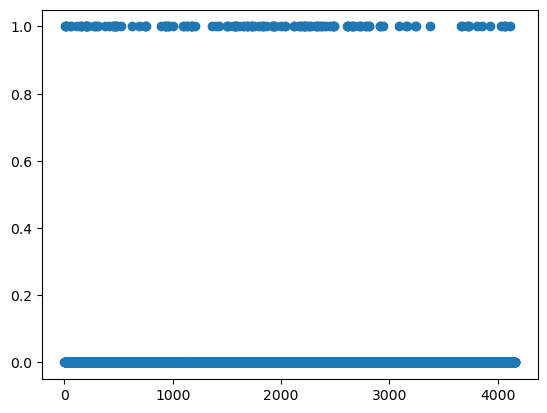

In [385]:
plt.scatter(X_train_lg.index.values, y_train_lg)

Looking at this graph, I'm somewhat surprised that this model was able to achieve results superior to the baseline, since many of the data points appear right on top of each other, and thus hard to classify as a scene with a character death as opposed to scene with no character death.

Now I will use my best model to predict the deathInScene column for all samples in the one_hot_scenes DataFrame. I will then aggregate this data at the episode level and produce a plot of the death data, by episode, from the model, against the original episode death data.

In [419]:
scene_death_predictions = rfit.predict(X)

In [420]:
one_hot_scenes['deathInScene'] = scene_death_predictions
one_hot_scenes.head(40)

,sceneStart,sceneEnd,Season Number,Episode Number,sceneDuration,totalCharacters,location_Astapor,location_Braavos,location_Dorne,location_Meereen,...,containsYoren,containsYoung Benjen Stark,containsYoung Cersei Lannister,containsYoung Lyanna Stark,containsYoung Nan,containsYoung Ned,containsYoung Ned Stark,containsYoung Rodrik Cassel,containsZanrush,deathInScene
0,40.0,105.0,1.0,1.0,65.0,3,0,0,0,0,...,False,False,False,False,False,False,False,False,False,0
1,105.0,204.0,1.0,1.0,99.0,3,0,0,0,0,...,False,False,False,False,False,False,False,False,False,0
2,204.0,211.0,1.0,1.0,7.0,2,0,0,0,0,...,False,False,False,False,False,False,False,False,False,0
3,211.0,218.0,1.0,1.0,7.0,1,0,0,0,0,...,False,False,False,False,False,False,False,False,False,0
4,218.0,224.0,1.0,1.0,6.0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,0
5,224.0,336.0,1.0,1.0,112.0,3,0,0,0,0,...,False,False,False,False,False,False,False,False,False,0
6,336.0,341.0,1.0,1.0,5.0,1,0,0,0,0,...,False,False,False,False,False,False,False,False,False,0
7,341.0,348.0,1.0,1.0,7.0,2,0,0,0,0,...,False,False,False,False,False,False,False,False,False,0
8,348.0,358.0,1.0,1.0,10.0,1,0,0,0,0,...,False,False,False,False,False,False,False,False,False,0
9,358.0,381.0,1.0,1.0,23.0,3,0,0,0,0,...,False,False,False,False,False,False,False,False,False,0


Aggregate the predicted deaths in scene by episode

In [421]:
predicted_deaths_per_episode = []

for season in episodes['seasonNum'].unique():
    
    # Each season can have a different number of episodes. Start iterating at episode 1, and go until one larger
    # than the upper bound of the number of episodes in that season (since the upper bound of range() is not
    # inclusive)
    for episode in range(1, np.max(episodes[episodes['seasonNum'] == season]['episodeNum'].unique()) + 1):
        
        # Add up all the deaths in the scene and append it to the deaths_per_episode list
        predicted_deaths_per_episode.append(np.sum(one_hot_scenes[(one_hot_scenes['Season Number'] == season) & (one_hot_scenes['Episode Number'] == episode)]['deathInScene']))

episodes['predictedDeathsPerEpisode'] = predicted_deaths_per_episode
episodes['predictedEpisodeContainsDeath'] = episodes['predictedDeathsPerEpisode'] > 0
episodes.head(20)

,seasonNum,episodeNum,deathsPerEpisode,episodeContainsDeath,predictedDeathsPerEpisode,predictedEpisodeContainsDeath
0,1,1,4,True,1,True
1,1,2,3,True,1,True
2,1,3,0,False,0,False
3,1,4,1,True,0,False
4,1,5,1,True,0,False
5,1,6,3,True,2,True
6,1,7,1,True,0,False
7,1,8,5,True,2,True
8,1,9,2,True,0,False
9,1,10,4,True,1,True


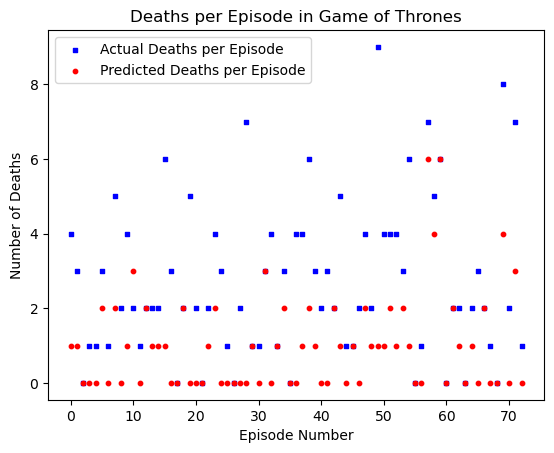

In [422]:
fig = plt.figure()
ax1 = fig.add_subplot(111)

ax1.scatter(episodes.index.values, episodes['deathsPerEpisode'], s=10, c='b', marker="s", label='Actual Deaths per Episode')
ax1.scatter(episodes.index.values, episodes['predictedDeathsPerEpisode'], s=10, c='r', marker="o", label='Predicted Deaths per Episode')
plt.legend(loc='upper left')

plt.xlabel('Episode Number')
plt.ylabel('Number of Deaths')
plt.title('Deaths per Episode in Game of Thrones')

plt.show()


Examine the average number of deaths per episode

In [423]:
np.mean(episodes['deathsPerEpisode'])

2.7534246575342465

What is the total error in the predictions? That is, for each episode, calculate the difference between the actual number of deaths in the episode and the predicted deaths in the episode and sum them.

In [424]:
np.sum(episodes['deathsPerEpisode'] - episodes['predictedDeathsPerEpisode'])

126

Now calculate this as a fraction of the total number of deaths.

In [425]:
np.sum(episodes['deathsPerEpisode'] - episodes['predictedDeathsPerEpisode']) / np.sum(episodes['deathsPerEpisode'])

0.6268656716417911

After balancing the classes with my random forest model, the results were noticeably better, though my model is still significantly underestimating deaths per episode. This isn't too surprising. Since the classes are so imbalanced, small errors (particularly false negatives, where a death occured in a scene but the model doesn't predict it) will be very noticeable in the final results, particularly because the total deaths in any episode are never above 10, and the majority contain less than 4. Therefore even one wrong prediction can have large effects.

**<h4>Linear Regression<h4>**

My first attempt at predicting the number of deaths per episode involved predicting at the scene level (since scenes contain many more features than entire episodes) and aggregating that data to get episode-level data. I will now try a linear regression to predict the number of episodes per death just from the episodes DataFrame

In [396]:
episodes

,seasonNum,episodeNum,deathsPerEpisode,episodeContainsDeath,predictedDeathsPerEpisode,predictedEpisodeContainsDeath
0,1,1,4,True,1,True
1,1,2,3,True,1,True
2,1,3,0,False,0,False
3,1,4,1,True,0,False
4,1,5,1,True,0,False
...,...,...,...,...,...,...
68,8,2,0,False,0,False
69,8,3,8,True,4,True
70,8,4,2,True,0,False
71,8,5,7,True,3,True


In [398]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

y = episodes['deathsPerEpisode']
X = episodes.drop(['deathsPerEpisode', 'predictedDeathsPerEpisode', 'predictedEpisodeContainsDeath'], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=5, test_size=0.3)                

lr.fit(X_train, y_train)

2023/12/07 01:07:53 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'd5072dba55484f9aa36469a4f6105a1b', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2023/12/07 01:07:53 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/Users/johnbrassey/opt/anaconda3/lib/python3.9/site-packages/mlflow/data/pandas_dataset.py:134: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers

LinearRegression()

In [399]:
lr.coef_

array([0.19475088, 0.275707  , 2.70431345])

In [403]:
from sklearn.metrics import mean_squared_error
y_pred = lr.predict(X_test)
mean_squared_error(y_pred, y_test, squared=False)

1.8312794588181152

Predict deaths per episode for all episode and plot results against the original deaths per episode data

In [404]:
episodes['predictedDeathsPerEpisode'] = lr.predict(X)
episodes

,seasonNum,episodeNum,deathsPerEpisode,episodeContainsDeath,predictedDeathsPerEpisode,predictedEpisodeContainsDeath
0,1,1,4,True,1.346911,True
1,1,2,3,True,1.622618,True
2,1,3,0,False,-0.805989,False
3,1,4,1,True,2.174032,False
4,1,5,1,True,2.449739,False
...,...,...,...,...,...,...
68,8,2,0,False,0.281560,False
69,8,3,8,True,3.261581,True
70,8,4,2,True,3.537288,False
71,8,5,7,True,3.812995,True


Plot the predicted deaths against the original deaths data

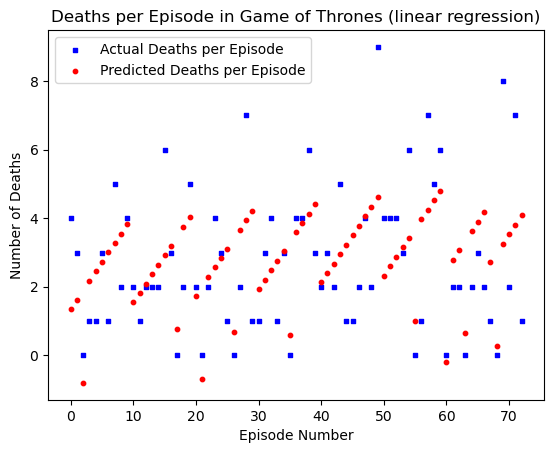

In [405]:
fig = plt.figure()
ax1 = fig.add_subplot(111)

ax1.scatter(episodes.index.values, episodes['deathsPerEpisode'], s=10, c='b', marker="s", label='Actual Deaths per Episode')
ax1.scatter(episodes.index.values, episodes['predictedDeathsPerEpisode'], s=10, c='r', marker="o", label='Predicted Deaths per Episode')
plt.legend(loc='upper left')

plt.xlabel('Episode Number')
plt.ylabel('Number of Deaths')
plt.title('Deaths per Episode in Game of Thrones (linear regression)')

plt.show()

Clearly, linear regression didn't end up being a good model for this data, which isn't surprising, given that the data isn't remotely linear. I just wanted to try an actual prediction algorithm on the episode-level data to see how it would do. Clearly that did not go well.

**<h4>Conclusion<h4>**

Overall, I am fairly pleased with my results, as well as my work on this project and how much I learned. My random forest model, once I balanced the classes, achieved a very high accuracy, and although it didn't necessarily look like it on the graph, since average deaths per episode were low, which magnified even small prediction errors, I think the results were quite good. I had a lot of fun, and I would be interested in doing more with this data set. In particular, I would eventually like to run a PCA in order to see how few features I can keep and still achieve similar accuracy results. Since I had several hundred features, I'm very curious as to which ones most influenced the model.